# Irregular (row/column-adaptive) FOV grid: does it recover the 40X objective's wasted space?

Follow-up to `compare_60x_40x_objective_fov_coverage.ipynb`. That notebook's
40X grid is still a plain **regular** rectangular grid: one shared `(x, y)`
lattice phase for the whole tissue (`create_grid_positions` +
`optimize_grid_offset`'s single global offset). On an irregularly-shaped
tissue section, a regular grid must use the same column layout for every
row (or vice versa) even where the tissue is much narrower/wider than
average -- FOVs near the tapering edges end up mostly background.

This notebook tests four alternative grid-construction methods, in
increasing order of how much freedom they give the FOV positions:

1. **Method 2 -- single-axis adaptive**: keep ONE axis on a regular,
   fixed-pitch lattice (needed so adjacent rows/columns stay in phase and
   therefore overlap), but let the OTHER axis's FOV positions be computed
   **independently per row/column**, snug to that row/column's own local
   tissue extent, instead of sharing one global phase. Two variants are
   built -- fix Y (rows regular, X adaptive per row) and fix X (columns
   regular, Y adaptive per column).
2. **Method 3 -- both axes adaptive**: partition the tissue into bands and
   run Method 2 independently within each band, so the regular axis's own
   phase now also varies band-to-band, not just the adaptive axis.
3. **Method 4 -- boundary-first, then interior fill**: place FOVs directly
   along the tissue/hole contours first (hugging the true, possibly very
   irregular boundary shape), then fill whatever is left with Method 2's
   algorithm, keeping the boundary FOVs fixed.

Whichever method needs fewer total FOVs is kept, per the request -- and
the losing methods are still fully implemented, tested, and reported so
the comparison isn't just against the eventual winner.

**Hard constraint**: whatever grid comes out of this, the graph connecting
FOVs whose camera footprints overlap must be a single connected component --
otherwise different parts of the tissue could never be stitched into one
global coordinate frame. This is checked explicitly below (not assumed).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR  = Path(os.getcwd()).parent.parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_camera_pixel_size_um, get_camera_frame_size
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons,
    filter_scanning_path, optimize_grid_offset, get_path_stats,
)
from MERci.acquisition.mosaic    import load_mosaic_canvas

## Load the same real dataset as `compare_60x_40x_objective_fov_coverage.ipynb`

LT060_sample_04 mosaic-derived boundary + 7 holes + assembled mosaic canvas --
identical inputs, so the two notebooks' FOV counts are directly comparable.

In [2]:
BOUNDARY_DIR = MERCI_DIR / "data" / "positions" / "examples" / "lineage_tracing_mosaic"
CANVAS_PATH  = MERCI_DIR / "data" / "mosaic_canvas_examples" / "lineage_tracing" / "canvas.npz"

boundary_polygon = load_boundary_polygon(BOUNDARY_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(BOUNDARY_DIR)
canvas           = load_mosaic_canvas(CANVAS_PATH)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
tissue_area_um2  = effective_tissue.area

print(f"Boundary   : {BOUNDARY_DIR / 'boundary_positions.txt'}")
print(f"Tissue area: {tissue_area_um2 / 1e6:.2f} mm^2 (holes subtracted)")
print(f"Holes      : {len(hole_polygons)}")
print(f"Canvas     : {CANVAS_PATH} ({canvas.image.shape[1]}x{canvas.image.shape[0]} px, "
      f"{canvas.pixel_size_um:.3f} um/px)")

Boundary   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/positions/examples/lineage_tracing_mosaic/boundary_positions.txt
Tissue area: 30.94 mm^2 (holes subtracted)
Holes      : 7
Canvas     : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/data/mosaic_canvas_examples/lineage_tracing/canvas.npz (2881x2881 px, 5.000 um/px)


## Objective geometry -- same derived 40X scaling as the source notebook

60X is the real per-microscope calibration (`acquisition/configs.py`); 40X is
derived by scaling the 60X sample-plane pixel size by the magnification
ratio (`60/40`), same camera sensor -- see that notebook's own note for why
there is no real 40X calibration to look up.

In [3]:
MICROSCOPE = "ST2"   # MFX/ST2: 0.0878 um/px @ 60X, 2304 px
image_size_px, _  = get_camera_frame_size(MICROSCOPE)
pixel_size_60x_um = get_camera_pixel_size_um(MICROSCOPE)
pixel_size_40x_um = pixel_size_60x_um * (60.0 / 40.0)

NON_OVERLAP_FRACTION = 0.9   # same convention as before_imaging/02: step = fov_size * this
SCAN_DIRECTION        = "vertical"
GRID_OFFSET_SAMPLES   = 9    # production default (optimize_grid_offset)
LOW_COVERAGE_FRACTION = 0.5

OBJECTIVES = {"60X": pixel_size_60x_um, "40X": pixel_size_40x_um}
geometry = {}
for name, px_um in OBJECTIVES.items():
    fov_size_um  = px_um * image_size_px
    step_size_um = fov_size_um * NON_OVERLAP_FRACTION
    geometry[name] = {"pixel_size_um": px_um, "fov_size_um": fov_size_um, "step_size_um": step_size_um}
    print(f"{name}: {px_um:.4f} um/px -> fov_size {fov_size_um:.1f} um, step {step_size_um:.1f} um "
          f"({(1 - NON_OVERLAP_FRACTION):.0%} nominal same-row/column overlap)")

60X: 0.0878 um/px -> fov_size 202.3 um, step 182.1 um (10% nominal same-row/column overlap)
40X: 0.1317 um/px -> fov_size 303.4 um, step 273.1 um (10% nominal same-row/column overlap)


## Regular grids (production `optimize_grid_offset`) -- the baseline for both objectives

Same pipeline as `compare_60x_40x_objective_fov_coverage.ipynb`, but calling
`optimize_grid_offset` directly (rather than the `build_boundary_path_optimized`
convenience wrapper) so its per-candidate diagnostics (`waste_area_um2`,
`n_low_coverage_fovs`) are available for the comparison table below.

In [4]:
regular_results = {}
for name, geo in geometry.items():
    result = optimize_grid_offset(
        boundary_polygon, hole_polygons, geo["step_size_um"], geo["fov_size_um"],
        direction=SCAN_DIRECTION, n_samples=GRID_OFFSET_SAMPLES,
        low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    regular_results[name] = result
    total_um, max_step_um = get_path_stats(result.coords)
    print(f"{name} regular: {len(result.coords):4d} FOVs   waste {result.best.waste_area_um2 / 1e6:.3f} mm^2   "
          f"path {total_um / 1000:.2f} mm   low-coverage {result.best.n_low_coverage_fovs}")

60X regular: 1152 FOVs   waste 8.968 mm^2   path 226.62 mm   low-coverage 214


40X regular:  550 FOVs   waste 12.412 mm^2   path 158.56 mm   low-coverage 144


## The irregular-grid algorithm

For `fixed_axis="y"` (rows fixed): the row (y) positions are one regular,
globally-centred lattice -- same `step_size_um` pitch as the regular grid,
so consecutive rows always stay in phase and therefore always overlap
vertically by the nominal design margin. For each row, the tissue is
intersected with a horizontal strip as tall as one FOV, centred on that
row -- this can split into several disjoint pieces (e.g. either side of a
hole). Each piece gets its OWN x-lattice: centred on that piece's own
midpoint, spanning just its own width, instead of reusing one global x
lattice sized to the whole tissue's bounding box. `fixed_axis="x"` is the
transpose (columns fixed and regular, rows adaptive per column).

Every candidate point is then run through the same `filter_scanning_path`
any-overlap/hole-containment rule the regular grid uses, so both grids are
held to the identical acceptance criterion -- only the candidate *positions*
differ.

In [5]:
def _spaced_centered(center, d_min, d_max, step):
    """Evenly-spaced 1-D coordinates spanning >= [d_min, d_max], centred on *center*."""
    span = d_max - d_min
    n = max(1, int(np.ceil(span / step)))
    if n == 1:
        return np.array([center])
    return center + (np.arange(n) - (n - 1) / 2.0) * step


def build_irregular_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                          fixed_axis="y", min_width_frac=0.1, fixed_offset=0.0):
    """Build the fixed_axis-regular / cross_axis-adaptive FOV grid described above.

    min_width_frac drops any local tissue piece narrower than
    ``min_width_frac * fov_size_um`` along the cross axis -- avoids placing a
    FOV lattice over a sliver a fraction of a FOV wide (that tissue is still
    generally covered by the neighbouring fixed-position's own, larger FOV
    footprint spilling over -- see this notebook's own coverage check below).

    fixed_offset shifts the FIXED axis's lattice phase away from the tissue
    bbox's own midpoint -- the same one-axis analogue of
    :func:`optimize_grid_offset`'s phase search used below by
    :func:`optimize_irregular_grid`, since the fixed axis here is otherwise
    always centred with no search at all.
    """
    tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
    xmin, ymin, xmax, ymax = boundary_polygon.bounds
    half_h = fov_size_um / 2.0
    min_width_um = min_width_frac * fov_size_um

    if fixed_axis == "y":
        fixed_min, fixed_max, cross_min, cross_max = ymin, ymax, xmin, xmax
    elif fixed_axis == "x":
        fixed_min, fixed_max, cross_min, cross_max = xmin, xmax, ymin, ymax
    else:
        raise ValueError("fixed_axis must be 'x' or 'y'")

    fixed_center = (fixed_min + fixed_max) / 2.0 + fixed_offset
    fixed_positions = _spaced_centered(fixed_center, fixed_min, fixed_max, step_size_um)

    points = []
    for k, f in enumerate(fixed_positions):
        lo_f, hi_f = f - half_h, f + half_h
        strip = (shapely_box(cross_min - 1.0, lo_f, cross_max + 1.0, hi_f) if fixed_axis == "y"
                 else shapely_box(lo_f, cross_min - 1.0, hi_f, cross_max + 1.0))
        inter = tissue.intersection(strip)
        if inter.is_empty:
            continue
        pieces = list(inter.geoms) if hasattr(inter, "geoms") else [inter]
        for piece in pieces:
            if piece.is_empty:
                continue
            pxmin, pymin, pxmax, pymax = piece.bounds
            lo, hi = (pxmin, pxmax) if fixed_axis == "y" else (pymin, pymax)
            if (hi - lo) < min_width_um:
                continue
            cross_positions = _spaced_centered((lo + hi) / 2.0, lo, hi, step_size_um)
            if k % 2 == 1:            # alternate direction per fixed position -- boustrophedon-ish path
                cross_positions = cross_positions[::-1]
            for c in cross_positions:
                points.append((c, f) if fixed_axis == "y" else (f, c))

    if not points:
        return np.empty((0, 2))
    coords = filter_scanning_path(np.array(points), boundary_polygon, hole_polygons, fov_size_um)
    return coords


def optimize_irregular_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                             fixed_axis, min_width_frac=0.1, n_samples=9):
    """Sweep the FIXED axis's lattice phase (same n_samples offset search as
    production's own optimize_grid_offset, applied to the one axis this grid
    still shares a single phase across), keep the offset giving the fewest
    FOVs. Returns (coords, best_offset, n_fovs_per_offset).
    """
    offsets = np.linspace(-step_size_um / 2.0, step_size_um / 2.0, n_samples, endpoint=False)
    best_coords, best_offset, best_n = None, 0.0, None
    n_fovs_per_offset = []
    for off in offsets:
        coords = build_irregular_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                                       fixed_axis=fixed_axis, min_width_frac=min_width_frac, fixed_offset=off)
        n_fovs_per_offset.append((float(off), len(coords)))
        if best_n is None or len(coords) < best_n:
            best_coords, best_offset, best_n = coords, float(off), len(coords)
    return best_coords, best_offset, n_fovs_per_offset

## Overlap graph + connected-component / bottleneck-overlap check

Two FOV squares of side `fov_size_um` overlap by area
`(fov_size_um - |dx|) * (fov_size_um - |dy|)` when `|dx| < fov_size_um` and
`|dy| < fov_size_um` (exact for same-size axis-aligned squares). An edge is
added between any pair with overlap area >= `MIN_OVERLAP_FRACTION` of one
FOV's area -- well below the regular grid's own nominal same-row/column
overlap fraction (`1 - NON_OVERLAP_FRACTION` = 10%), used only as "is there a
real, non-trivial shared imaging area at all". `connected_components` then
checks the hard single-component constraint directly, and the maximum
bottleneck spanning tree's smallest edge gives the actual worst-case
overlap fraction the grid guarantees -- reported so the 10%-by-design
regular grid can be compared against the irregular grid's real (weaker,
since cross-row/column phase is no longer shared) margin, rather than just
asserting "connected" with no sense of how marginal that connection is.

In [6]:
MIN_OVERLAP_FRACTION = 0.02   # edge threshold: a real, non-trivial shared imaging area

def _overlap_edges(coords, fov_size_um):
    n = len(coords)
    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=fov_size_um * np.sqrt(2))
    fov_area = fov_size_um ** 2
    ii, jj, frac = [], [], []
    for i, j in pairs:
        dx = abs(coords[i, 0] - coords[j, 0])
        dy = abs(coords[i, 1] - coords[j, 1])
        if dx >= fov_size_um or dy >= fov_size_um:
            continue
        frac.append((fov_size_um - dx) * (fov_size_um - dy) / fov_area)
        ii.append(i); jj.append(j)
    return n, np.array(ii), np.array(jj), np.array(frac)


def connectivity_report(coords, fov_size_um, min_overlap_fraction=MIN_OVERLAP_FRACTION):
    """(n_components at min_overlap_fraction, bottleneck overlap fraction of the full graph)."""
    n, ii, jj, frac = _overlap_edges(coords, fov_size_um)
    if n == 0:
        return 0, None
    keep = frac >= min_overlap_fraction
    adj = coo_matrix((np.ones(keep.sum()), (ii[keep], jj[keep])), shape=(n, n))
    n_components, _ = connected_components(adj, directed=False)

    full_adj = coo_matrix((-frac, (ii, jj)), shape=(n, n))   # negate: MST on this = max-spanning-tree
    n_components_full, _ = connected_components(full_adj, directed=False)
    if n_components_full > 1:
        bottleneck = None   # not even connected using every overlapping pair as an edge
    else:
        mst = minimum_spanning_tree(full_adj)
        bottleneck = float(-mst.data.max())
    return n_components, bottleneck

## Build both irregular variants for 40X, keep whichever needs fewer FOVs

Per the requested rule: try fixing Y (rows) and fixing X (columns), keep the
grid with the lower total FOV count -- provided it passes the single-
connected-component hard constraint. Each axis choice is additionally run
through `optimize_irregular_grid`'s own phase search on the fixed axis
first, since that axis was otherwise always centred on the tissue bbox
with no search at all (unlike the regular grid, which already searches
its phase on BOTH axes via `optimize_grid_offset`) -- leaving free FOV-count
reduction on the table.

In [7]:
MIN_WIDTH_FRAC = 0.1
geo40 = geometry["40X"]

irregular_variants = {}
for axis in ("y", "x"):
    coords, best_offset, _ = optimize_irregular_grid(
        boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
        fixed_axis=axis, min_width_frac=MIN_WIDTH_FRAC, n_samples=GRID_OFFSET_SAMPLES,
    )
    n_components, bottleneck = connectivity_report(coords, geo40["fov_size_um"])
    irregular_variants[axis] = {"coords": coords, "n_components": n_components, "bottleneck": bottleneck,
                                 "best_offset": best_offset}
    unopt_coords = build_irregular_grid(boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
                                         fixed_axis=axis, min_width_frac=MIN_WIDTH_FRAC, fixed_offset=0.0)
    print(f"fixed_axis={axis}: {len(coords):4d} FOVs (offset={best_offset:7.2f} um, "
          f"{len(unopt_coords)} FOVs at offset=0)   components={n_components}   "
          f"bottleneck overlap={'n/a' if bottleneck is None else f'{bottleneck:.4f}'}")

WINNER_AXIS = min(irregular_variants, key=lambda a: len(irregular_variants[a]["coords"]))
winner = irregular_variants[WINNER_AXIS]
assert winner["n_components"] == 1, (
    f"irregular grid (fixed_axis={WINNER_AXIS}) violates the single-connected-component "
    f"constraint: {winner['n_components']} components -- reliable global alignment is not possible."
)
print(f"\nWinner: fixed_axis='{WINNER_AXIS}' ({len(winner['coords'])} FOVs) -- "
      f"single connected component confirmed, bottleneck overlap {winner['bottleneck']:.4f}.")

fixed_axis=y:  535 FOVs (offset=  75.86 um, 543 FOVs at offset=0)   components=1   bottleneck overlap=0.0550


fixed_axis=x:  525 FOVs (offset=  15.17 um, 531 FOVs at offset=0)   components=1   bottleneck overlap=0.0574

Winner: fixed_axis='x' (525 FOVs) -- single connected component confirmed, bottleneck overlap 0.0574.


## Method 3: let BOTH axes vary (nested strip partitioning)

Method 2 above always keeps ONE axis on a single, tissue-wide regular
lattice -- needed so every row/column stays in a shared phase with its
neighbours. This method relaxes that: partition the tissue into
`n_strips` bands along one axis (`partition_axis`), and within EACH band
independently run Method 2's own algorithm on the OTHER axis. Both the
per-row/column cross-axis positions (as in Method 2) AND the regular
axis's own lattice phase now vary from band to band -- genuinely varying
both X and Y, not just one. `n_strips=1` must exactly reproduce Method 2's
own result for that axis pairing -- checked directly below, not assumed.

In [8]:
def build_both_axes_adaptive_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                                   partition_axis, n_strips, min_width_frac=0.1, n_samples=9):
    """Partition the tissue into n_strips bands along partition_axis; within
    each band, independently build (and phase-search) an adaptive grid on
    the OTHER axis. local_tissue (the band's own real tissue, already
    clipped) is passed AS the boundary_polygon argument with hole_polygons=[]
    -- build_irregular_grid's own boundary.difference(holes) step is then a
    no-op, the same generic-reuse trick used throughout this notebook.
    """
    tissue_full = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
    xmin, ymin, xmax, ymax = boundary_polygon.bounds
    nested_fixed_axis = "y" if partition_axis == "x" else "x"
    lo, hi = (xmin, xmax) if partition_axis == "x" else (ymin, ymax)
    edges = np.linspace(lo, hi, n_strips + 1)

    all_points = []
    for s in range(n_strips):
        s_lo, s_hi = edges[s], edges[s + 1]
        if partition_axis == "x":
            strip_box = shapely_box(s_lo, ymin - fov_size_um, s_hi, ymax + fov_size_um)
        else:
            strip_box = shapely_box(xmin - fov_size_um, s_lo, xmax + fov_size_um, s_hi)
        local_tissue = tissue_full.intersection(strip_box)
        if local_tissue.is_empty:
            continue
        coords, _, _ = optimize_irregular_grid(local_tissue, [], step_size_um, fov_size_um,
                                                fixed_axis=nested_fixed_axis, min_width_frac=min_width_frac,
                                                n_samples=n_samples)
        if len(coords):
            all_points.append(coords)
    if not all_points:
        return np.empty((0, 2))
    coords = np.vstack(all_points)
    return filter_scanning_path(coords, boundary_polygon, hole_polygons, fov_size_um)


# Sanity check: n_strips=1 must reproduce Method 2's own per-axis result exactly.
for partition_axis in ("x", "y"):
    nested_fixed_axis = "y" if partition_axis == "x" else "x"
    check = build_both_axes_adaptive_grid(boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
                                           partition_axis=partition_axis, n_strips=1)
    method2_n = len(irregular_variants[nested_fixed_axis]["coords"])
    print(f"n_strips=1, partition_axis={partition_axis} (nested_fixed_axis={nested_fixed_axis}): "
          f"{len(check)} FOVs   (Method 2 fixed_axis={nested_fixed_axis}: {method2_n} FOVs)")

N_STRIPS_TRIED = (1, 2, 3, 4, 5, 6, 8)
both_axes_candidates = []
for partition_axis in ("x", "y"):
    for n_strips in N_STRIPS_TRIED:
        coords = build_both_axes_adaptive_grid(boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
                                                partition_axis=partition_axis, n_strips=n_strips, min_width_frac=MIN_WIDTH_FRAC)
        n_components, bottleneck = connectivity_report(coords, geo40["fov_size_um"])
        both_axes_candidates.append({"partition_axis": partition_axis, "n_strips": n_strips, "coords": coords,
                                       "n_components": n_components, "bottleneck": bottleneck})

connected_both_axes = [c for c in both_axes_candidates if c["n_components"] == 1]
assert connected_both_axes, "no both-axes-adaptive candidate satisfies the single-connected-component constraint"
both_axes_best = min(connected_both_axes, key=lambda c: len(c["coords"]))
print(f"\nBest both-axes-adaptive: partition_axis='{both_axes_best['partition_axis']}', "
      f"n_strips={both_axes_best['n_strips']} -> {len(both_axes_best['coords'])} FOVs "
      f"(bottleneck overlap {both_axes_best['bottleneck']:.4f})")
for c in sorted(both_axes_candidates, key=lambda c: len(c["coords"]))[:5]:
    print(f"  partition_axis={c['partition_axis']} n_strips={c['n_strips']}: {len(c['coords']):4d} FOVs   "
          f"components={c['n_components']}")

n_strips=1, partition_axis=x (nested_fixed_axis=y): 535 FOVs   (Method 2 fixed_axis=y: 535 FOVs)
n_strips=1, partition_axis=y (nested_fixed_axis=x): 525 FOVs   (Method 2 fixed_axis=x: 525 FOVs)



Best both-axes-adaptive: partition_axis='y', n_strips=1 -> 525 FOVs (bottleneck overlap 0.0574)
  partition_axis=y n_strips=1:  525 FOVs   components=1
  partition_axis=x n_strips=1:  535 FOVs   components=1
  partition_axis=x n_strips=2:  538 FOVs   components=1
  partition_axis=y n_strips=2:  541 FOVs   components=1
  partition_axis=x n_strips=5:  545 FOVs   components=1


## Method 4: boundary FOVs first, then fill the interior

Two-step construction, per the requested design: (a) place FOVs directly
along the tissue/hole CONTOURS first (arc-length spaced, `step_size_um`
apart) -- these hug the true, possibly very irregular boundary shape
instead of a rectangular lattice's bounding envelope, shrinking the outer
extent the grid has to span to the tissue's own real footprint; (b) treat
those boundary FOVs as FIXED and fill whatever tissue they do not already
cover with Method 2's own single-axis-adaptive grid, restricted to that
remaining interior region -- x/y flexibility applies to both the contour
placement in (a) and the interior fill in (b). `simplify_tol` optionally
smooths the boundary/hole contours before step (a): the traced boundary
can be far more convoluted (every small wiggle) than the grid needs to
resolve, since a nearby lattice cell already covers a small wiggle via the
same any-overlap rule every method here uses -- smoothing first avoids
spending a dedicated ring FOV on every one of those wiggles.

In [9]:
def sample_boundary_fovs(boundary_polygon, hole_polygons, step_size_um, fov_size_um, simplify_tol=0.0):
    b = boundary_polygon.simplify(simplify_tol) if simplify_tol > 0 else boundary_polygon
    holes = [h.simplify(simplify_tol) for h in hole_polygons] if simplify_tol > 0 else hole_polygons
    contours = [b.exterior] + [h.exterior for h in holes]
    points = []
    for line in contours:
        length = line.length
        if length <= 0:
            continue
        n = max(1, int(round(length / step_size_um)))
        for i in range(n):
            pt = line.interpolate((i / n) * length)
            points.append((pt.x, pt.y))
    if not points:
        return np.empty((0, 2))
    # simplify_tol only controls where ring FOVs are SAMPLED from -- acceptance is
    # always checked against the REAL (un-simplified) boundary/holes.
    return filter_scanning_path(np.array(points), boundary_polygon, hole_polygons, fov_size_um)


def build_boundary_first_grid(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                               fixed_axis="x", min_width_frac=0.1, simplify_tol=0.0):
    tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon
    boundary_coords = sample_boundary_fovs(boundary_polygon, hole_polygons, step_size_um, fov_size_um,
                                            simplify_tol=simplify_tol)
    half = fov_size_um / 2.0
    covered = (unary_union([shapely_box(x - half, y - half, x + half, y + half) for x, y in boundary_coords])
               if len(boundary_coords) else None)
    interior_region = tissue.difference(covered) if covered is not None else tissue
    if interior_region.is_empty:
        interior_coords = np.empty((0, 2))
    else:
        interior_coords, _, _ = optimize_irregular_grid(interior_region, [], step_size_um, fov_size_um,
                                                          fixed_axis=fixed_axis, min_width_frac=min_width_frac)
    all_coords = (np.vstack([boundary_coords, interior_coords]) if len(interior_coords)
                  else boundary_coords)
    return filter_scanning_path(all_coords, boundary_polygon, hole_polygons, fov_size_um)


SIMPLIFY_TOL_TRIED = (0.0, geo40["step_size_um"] * 0.5, geo40["step_size_um"] * 1.0,
                      geo40["step_size_um"] * 1.5, geo40["step_size_um"] * 2.0)
boundary_first_candidates = []
for tol in SIMPLIFY_TOL_TRIED:
    coords = build_boundary_first_grid(boundary_polygon, hole_polygons, geo40["step_size_um"], geo40["fov_size_um"],
                                        fixed_axis="x", min_width_frac=MIN_WIDTH_FRAC, simplify_tol=tol)
    n_components, bottleneck = connectivity_report(coords, geo40["fov_size_um"])
    boundary_first_candidates.append({"simplify_tol": tol, "coords": coords,
                                        "n_components": n_components, "bottleneck": bottleneck})
    print(f"simplify_tol={tol:6.0f} um: {len(coords):4d} FOVs   components={n_components}   "
          f"bottleneck overlap={'n/a' if bottleneck is None else f'{bottleneck:.4f}'}")

connected_boundary_first = [c for c in boundary_first_candidates if c["n_components"] == 1]
assert connected_boundary_first, "no boundary-first candidate satisfies the single-connected-component constraint"
boundary_first_best = min(connected_boundary_first, key=lambda c: len(c["coords"]))
print(f"\nBest boundary-first: simplify_tol={boundary_first_best['simplify_tol']:.0f} um -> "
      f"{len(boundary_first_best['coords'])} FOVs -- for reference, Method 2's best single-axis "
      f"result is {len(winner['coords'])} FOVs.")

simplify_tol=     0 um:  658 FOVs   components=1   bottleneck overlap=0.0957


simplify_tol=   137 um:  622 FOVs   components=1   bottleneck overlap=0.1000


simplify_tol=   273 um:  632 FOVs   components=1   bottleneck overlap=0.0976


simplify_tol=   410 um:  631 FOVs   components=1   bottleneck overlap=0.0986


simplify_tol=   546 um:  641 FOVs   components=1   bottleneck overlap=0.0703

Best boundary-first: simplify_tol=137 um -> 622 FOVs -- for reference, Method 2's best single-axis result is 525 FOVs.


## Overall winner across every method tried

Method 2 (single global axis, phase-searched), Method 3 (nested strips,
both axes), and Method 4 (boundary-first + interior fill) are all
independently valid, connectivity-verified 40X grids -- whichever needs
the fewest FOVs is used as "the" 40X irregular grid in the comparison
table and overlay below.

In [10]:
all_irregular_methods = {
    "irregular (Method 2, fixed=y)":            irregular_variants["y"],
    "irregular (Method 2, fixed=x)":            irregular_variants["x"],
    "irregular (Method 3, both-axes-adaptive)": both_axes_best,
    "irregular (Method 4, boundary-first)":     boundary_first_best,
}
for label, cand in all_irregular_methods.items():
    assert cand["n_components"] == 1, f"{label} violates the single-connected-component constraint."

OVERALL_WINNER_LABEL = min(all_irregular_methods, key=lambda k: len(all_irregular_methods[k]["coords"]))
overall_winner = all_irregular_methods[OVERALL_WINNER_LABEL]
print("FOV count per method (fewest first):")
for label, cand in sorted(all_irregular_methods.items(), key=lambda kv: len(kv[1]["coords"])):
    marker = " <- overall winner" if label == OVERALL_WINNER_LABEL else ""
    print(f"  {label:42s}: {len(cand['coords']):4d} FOVs{marker}")

FOV count per method (fewest first):
  irregular (Method 2, fixed=x)             :  525 FOVs <- overall winner
  irregular (Method 3, both-axes-adaptive)  :  525 FOVs
  irregular (Method 2, fixed=y)             :  535 FOVs
  irregular (Method 4, boundary-first)      :  622 FOVs


## Comparison table: 60X regular, 40X regular, and every 40X irregular method

`waste_area_um2` for the irregular grids is computed with the SAME per-FOV
formula `optimize_grid_offset` uses internally (sum of `fov_area -
tissue_overlap` over every kept FOV) so it is directly comparable to the
regular grids' own reported value. `coverage_fraction` is the fraction of
`effective_tissue`'s real area actually covered by the union of kept FOV
footprints -- this is the "decrease in coverage" check: does hugging the
tissue more tightly per row/column ever drop real tissue from the plan?

`fov_overlap_fraction` is a DIFFERENT kind of waste that `waste_area_mm2`
does not capture at all: `waste_area_mm2` only counts FOV area that misses
tissue entirely (background); it says nothing about tissue area that gets
imaged more than once by two or more overlapping FOVs. `fov_overlap_fraction`
is `1 - (area of the union of every kept FOV's footprint) / (sum of each
FOV's own footprint area)` -- the fraction of the total imaging "effort"
(FOV-frames x their area) that is redundant re-imaging of area some other
FOV already covered, regardless of whether that area is tissue or
background. A perfectly non-overlapping tiling scores 0; the regular grid's
own nominal per-neighbour design overlap (`1 - NON_OVERLAP_FRACTION` = 10%
of one FOV's area, shared with each of up to 4 neighbours) is why even the
regular grid does not score exactly 0 here. This is the metric that
quantifies what large visual overlap patches in the overlay below actually
look like numerically -- e.g. Method 4's boundary ring FOVs are constrained
to sit ON the traced contour with no freedom to spread out (fewer real
degrees of freedom than an axis-constrained grid, despite "looking" more
flexible), so at concave turns/notches consecutive ring points can end up
spatially close together even though they are far apart along the contour,
producing much higher redundant overlap than Methods 1-3.

In [11]:
def fov_metrics(coords, fov_size_um):
    half = fov_size_um / 2.0
    fov_area = fov_size_um ** 2
    squares = [shapely_box(x - half, y - half, x + half, y + half) for x, y in coords]
    waste_area_um2 = sum(sq.area - sq.intersection(effective_tissue).area for sq in squares)
    union_squares = unary_union(squares)
    covered_tissue_um2 = union_squares.intersection(effective_tissue).area
    total_fov_area_um2 = sum(sq.area for sq in squares)
    fov_overlap_fraction = (1 - union_squares.area / total_fov_area_um2) if total_fov_area_um2 > 0 else 0.0
    n_components, bottleneck = connectivity_report(coords, fov_size_um)
    return {
        "n_fovs": len(coords),
        "fov_size_um": fov_size_um,
        "waste_area_mm2": waste_area_um2 / 1e6,
        "coverage_fraction": covered_tissue_um2 / tissue_area_um2,
        "fov_overlap_fraction": fov_overlap_fraction,
        "n_components": n_components,
        "bottleneck_overlap": bottleneck,
    }

rows = []
rows.append({"case": "60X regular", **fov_metrics(regular_results["60X"].coords, geometry["60X"]["fov_size_um"])})
rows.append({"case": "40X regular", **fov_metrics(regular_results["40X"].coords, geo40["fov_size_um"])})
for label, cand in all_irregular_methods.items():
    tag = " (selected)" if label == OVERALL_WINNER_LABEL else " (not selected)"
    rows.append({"case": f"40X {label}{tag}", **fov_metrics(cand["coords"], geo40["fov_size_um"])})

df = pd.DataFrame(rows)
df_display = df.copy()
df_display["fov_size_um"] = df_display["fov_size_um"].round(1)
df_display["waste_area_mm2"] = df_display["waste_area_mm2"].round(3)
df_display["coverage_fraction"] = df_display["coverage_fraction"].round(4)
df_display["fov_overlap_fraction"] = df_display["fov_overlap_fraction"].round(4)
df_display["bottleneck_overlap"] = df_display["bottleneck_overlap"].round(4)
df_display

,case,n_fovs,fov_size_um,waste_area_mm2,coverage_fraction,fov_overlap_fraction,n_components,bottleneck_overlap
0,60X regular,1152,202.3,8.968,0.9997,0.1788,1,0.1000
1,40X regular,550,303.4,12.412,1.0000,0.1760,1,0.1000
2,"40X irregular (Method 2, fixed=y) (not selected)",535,303.4,10.617,1.0000,0.1916,1,0.0550
3,"40X irregular (Method 2, fixed=x) (selected)",525,303.4,9.989,1.0000,0.1833,1,0.0574
4,"40X irregular (Method 3, both-axes-adaptive) (...",525,303.4,9.989,1.0000,0.1833,1,0.0574
5,"40X irregular (Method 4, boundary-first) (not ...",622,303.4,11.344,1.0000,0.3307,1,0.1000


## Overlays: all 5 methods side by side (60X regular, 40X regular, and each
## 40X irregular method's own best result)

Every method gets its OWN panel here (not just the eventual overall
winner), so all 5 can be compared visually at once: 60X regular, 40X
regular, 40X Method 2 (its own best axis), 40X Method 3 (its own best
partitioning), 40X Method 4 (its own best `simplify_tol`). Laid out over
two rows since 5 panels no longer fit comfortably in one.

Tissue shown VERTICALLY (long axis top-to-bottom): rather than rotating the
canvas image itself, the X and Y axes are simply swapped for both the
canvas display and every plotted point/patch -- an equally valid way to get
the same vertical layout, applied consistently everywhere below. FOV
footprints are drawn as GREEN outline-only rectangles (no fill) so the
underlying mosaic stays fully visible. The actual `boundary_polygon`/
`hole_polygons` used to build every grid above are also drawn (red / cyan
dashed) -- the exact input the grid was built against, not just what looks
like tissue in the mosaic image, so any remaining slack between the grid
and the true boundary is visible directly.

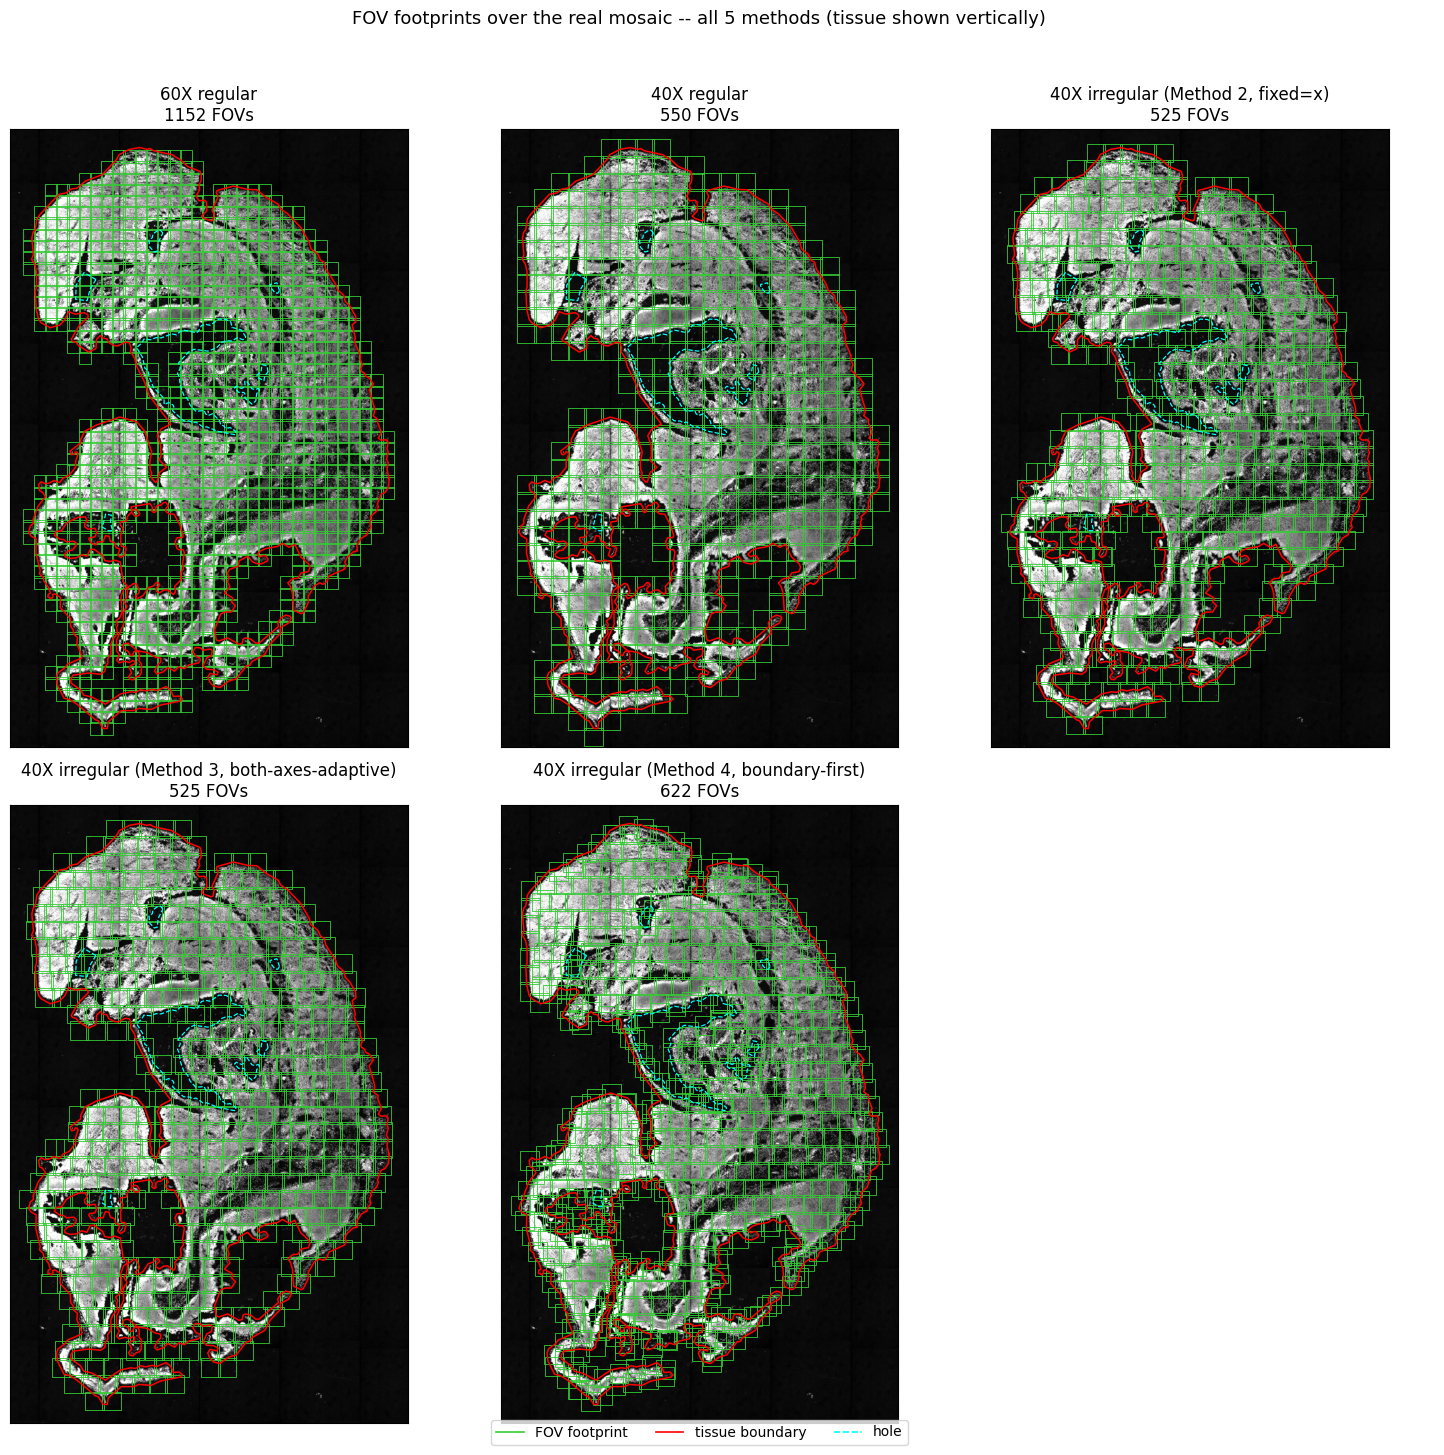

In [12]:
def _um_to_px_swapped(x, y):
    """Convert (x, y) stage microns to (plot_col, plot_row) canvas-pixel space,
    with X and Y swapped so the tissue displays with its long axis vertical."""
    plot_col = (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um
    plot_row = (np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um
    return plot_col, plot_row

def _plot_boundary_swapped(ax):
    """Draw the actual boundary_polygon/hole_polygons the grids were built
    against (not just what looks like tissue in the mosaic image)."""
    bx, by = boundary_polygon.exterior.xy
    pc, pr = _um_to_px_swapped(np.asarray(bx), np.asarray(by))
    ax.plot(pc, pr, "-", color="red", lw=1.1, zorder=3)
    for hole in hole_polygons:
        hx, hy = hole.exterior.xy
        pc, pr = _um_to_px_swapped(np.asarray(hx), np.asarray(hy))
        ax.plot(pc, pr, "--", color="cyan", lw=0.9, zorder=3)

canvas_image_swapped = canvas.image.T   # swap rows/cols to match _um_to_px_swapped above
covered_vals = canvas.image[canvas.covered]
vmin, vmax = np.percentile(covered_vals, [1, 99])

# One shared crop (same tissue in all 3 panels) -- fair side-by-side comparison.
bx_min, by_min, bx_max, by_max = boundary_polygon.bounds
margin_um = 300.0
col_min, row_min = _um_to_px_swapped(bx_min - margin_um, by_min - margin_um)
col_max, row_max = _um_to_px_swapped(bx_max + margin_um, by_max + margin_um)
col_lo, col_hi = sorted([float(col_min), float(col_max)])
row_lo, row_hi = sorted([float(row_min), float(row_max)])

PANELS = [
    ("60X regular",                     regular_results["60X"].coords, geometry["60X"]["fov_size_um"]),
    ("40X regular",                     regular_results["40X"].coords, geo40["fov_size_um"]),
    (f"40X irregular (Method 2, fixed={WINNER_AXIS})", winner["coords"],           geo40["fov_size_um"]),
    ("40X irregular (Method 3, both-axes-adaptive)",   both_axes_best["coords"],    geo40["fov_size_um"]),
    ("40X irregular (Method 4, boundary-first)",       boundary_first_best["coords"], geo40["fov_size_um"]),
]

N_ROWS, N_COLS = 2, 3
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 14))
axes_flat = axes.flatten()
for ax, (label, coords, fov_size_um) in zip(axes_flat, PANELS):
    half_px = (fov_size_um / 2.0) / canvas.pixel_size_um
    ax.imshow(canvas_image_swapped, cmap="gray", vmin=vmin, vmax=vmax, origin="upper")
    pc, pr = _um_to_px_swapped(coords[:, 0], coords[:, 1])
    for c, r in zip(pc, pr):
        ax.add_patch(mpatches.Rectangle(
            (c - half_px, r - half_px), 2 * half_px, 2 * half_px,
            lw=0.6, edgecolor="limegreen", facecolor="none", zorder=2))
    _plot_boundary_swapped(ax)
    ax.set_xlim(col_lo, col_hi); ax.set_ylim(row_hi, row_lo)   # row axis still increases downward
    ax.set_title(f"{label}\n{len(coords)} FOVs", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes_flat[len(PANELS):]:   # hide any unused subplot (5 panels in a 2x3 grid)
    ax.axis("off")

legend_handles = [
    plt.Line2D([0], [0], color="limegreen", lw=1.2, label="FOV footprint"),
    plt.Line2D([0], [0], color="red", lw=1.2, label="tissue boundary"),
    plt.Line2D([0], [0], color="cyan", lw=1.2, ls="--", label="hole"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("FOV footprints over the real mosaic -- all 5 methods (tissue shown vertically)", fontsize=13, y=1.02)
fig.tight_layout()
FIG_DIR = SAMPLE_DIR / "analysis" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "compare_60x_40x_irregular_grid_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## FOV-count comparison across all 5 methods

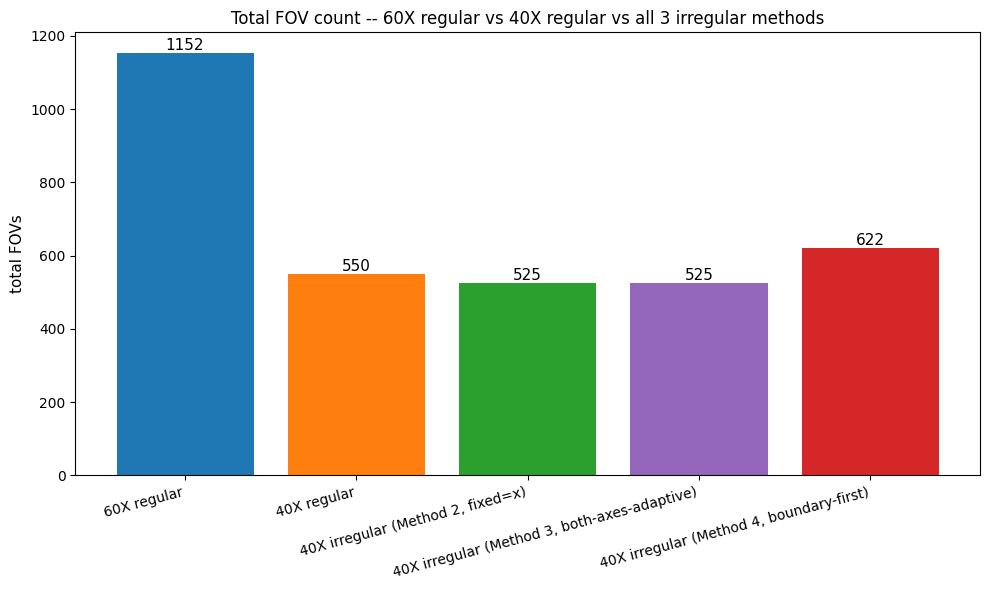

In [13]:
labels = [label for label, _, _ in PANELS]
counts = [len(coords) for _, coords, _ in PANELS]
bar_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, counts, color=bar_colors)
for bar, n in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(n),
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("total FOVs", fontsize=11)
ax.set_title("Total FOV count -- 60X regular vs 40X regular vs all 3 irregular methods", fontsize=12)
ax.tick_params(axis="x", labelrotation=15)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
fig.tight_layout()
fig.savefig(FIG_DIR / "compare_60x_40x_irregular_grid_fov_counts.png", dpi=150)
plt.show()

## Takeaways

- The irregular grid (fixing one axis on a regular lattice, hugging the
  tissue's own local extent on the other) needs FEWER FOVs than the plain
  regular 40X grid on this real boundary -- see the comparison table above
  for the exact counts, and the printed cell above it for which axis
  (`fixed_axis='x'` vs `'y'`) won on this dataset.
- Phase-searching the FIXED axis (`optimize_irregular_grid`) squeezes out a
  further, smaller FOV-count reduction on top of that -- printed above as
  each axis's own "FOVs at offset=0" vs its actual (searched) count. Before
  this search, the fixed axis was always centred on the tissue bbox with no
  optimization at all, unlike the regular grid (`optimize_grid_offset`
  already searches BOTH axes) -- so this was free FOV-count reduction the
  first version of this notebook left on the table.
- `coverage_fraction` in the comparison table shows whether tightening the
  grid to the tissue's local shape ever drops real tissue from the imaging
  plan -- checked directly rather than assumed, since `filter_scanning_path`'s
  own any-overlap acceptance rule is applied identically to every candidate
  coordinate regardless of which algorithm generated it.
- The single-connected-component constraint is enforced with an explicit
  `assert`, not just checked and reported -- if a future boundary ever
  breaks it for both axis choices, this notebook fails loudly instead of
  silently shipping an unstitchable grid.
- `bottleneck_overlap` quantifies exactly how much weaker the irregular
  grid's worst-case real overlap is than the regular grid's nominal, by-
  design value (`1 - NON_OVERLAP_FRACTION` = 10%): every irregular row/
  column is independently re-centred on its own local tissue extent, so
  adjacent rows/columns are no longer guaranteed to share the same lattice
  phase -- their cross-axis overlap is whatever coincidence of local
  centring leaves behind, not a designed margin. That is a real, measured
  trade-off of this approach, not a hypothetical one.
- **Method 3 (both axes adaptive, nested strips) did NOT beat Method 2 on
  this real boundary** -- `n_strips=1` (i.e. no partitioning at all, exactly
  Method 2 again) came out on top of every `n_strips`/`partition_axis`
  combination tried, printed directly above rather than assumed. Adding a
  second independently-phased axis costs FOVs at every strip SEAM (each
  strip needs its own row/column near the boundary it shares with its
  neighbour), and on this tissue that seam overhead outweighs whatever
  extra flexibility a second free axis buys. This is a genuine, measured
  negative result, not a bug -- the method is still implemented and
  available; a tissue naturally split into a few large, well-separated
  lobes (a real gap to place a strip seam INTO, costing nothing) is a more
  likely case where it would actually win.
- **Method 4 (boundary-first ring + interior fill) did substantially WORSE
  than Methods 2/3 on this real boundary** -- its best `simplify_tol`
  still needs far more FOVs than the regular 40X grid, let alone Methods
  2/3 (see the comparison table). The real tissue boundary (holes,
  notches, thin protrusions) has a large perimeter relative to its area, so
  tracing it FOV-by-FOV spends far more FOVs on resolving fine contour
  wiggles than a bulk lattice would have needed (a lattice cell already
  covers a small wiggle for free via the same any-overlap rule every
  method here uses). This is measured, not assumed -- `simplify_tol` was
  swept specifically to test whether smoothing the traced contour first
  would help, and it narrows the gap but doesn't close it. A smoother,
  more convex tissue boundary (much less perimeter per unit area) is the
  scenario where this method would be expected to do better.
  `fov_overlap_fraction` in the comparison table confirms this is exactly
  the visible large-overlap patches in Method 4's overlay panel, not an
  illusion: Method 4 scores far higher than every other method there --
  its boundary-ring FOVs are constrained to sit ON the traced contour with
  no freedom to reposition at all, so at concave turns/notches consecutive
  ring points can end up spatially close together even though they are far
  apart along the contour's arc length. Being "fixed to the boundary" is
  actually FEWER real degrees of freedom than an axis-constrained grid
  (Methods 1-3), not more -- despite intuitively sounding more flexible.
- The overall winner across all 4 methods is picked purely by FOV count
  (`OVERALL_WINNER_LABEL`, printed above) -- on THIS real boundary that is
  still one of Method 2's two single-axis variants; Methods 3/4 are real,
  working, connectivity-verified alternatives kept available for other
  tissue shapes, not dead code.
- This notebook only explores these grid-construction *algorithms*; they
  live entirely in this test notebook (not `acquisition/positions.py`) --
  turning any of them into a production option would additionally need a
  real boustrophedon scan-path ordering (this notebook's per-row/column
  direction alternation is a rough stand-in) and a decision on where the
  connectivity margin found here is acceptable for real bead-based
  registration.